# Webinar 1 — Vectores & Recomendación de Películas
**Álgebra lineal aplicada para Data Science**

---

## Agenda
| # | Bloque | 
|---|--------|
| 1 | Vectores en Python | 
| 2 | Operaciones vectoriales | 
| 3 | Norma, producto escalar y similitud coseno | 
| 4 | Construir el recomendador | 
| 5 | Cierre + Q&A | 

**Al terminar vas a poder:**
- Representar datos como vectores en NumPy
- Implementar similitud coseno desde cero
- Explicar por qué normalizar importa
- Construir un recomendador de películas funcional

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
print('✅ Listo')

✅ Listo


---
# PARTE 1 — Vectores: el lenguaje de las máquinas

Un **vector** es una lista ordenada de números.  
En Machine Learning, cada usuario, producto o documento se representa como un vector.

**Ejemplo:** Sistema de recomendación de películas.  
Cada usuario tiene ratings (1-5) para 5 géneros: Acción, Romance, Comedia, Terror, Sci-Fi.

In [25]:
# Cada usuario es un vector de ratings por género
# Orden: [Accion, Romance, Comedia, Terror, Sci-Fi]


ana = np.array([5, 2, 3, 0, 4])
carlos = np.array([4, 5, 2, 1, 3])
sofia = np.array([1, 2, 5, 4, 3])
miguel = np.array([2, 1, 4, 5, 3])
 

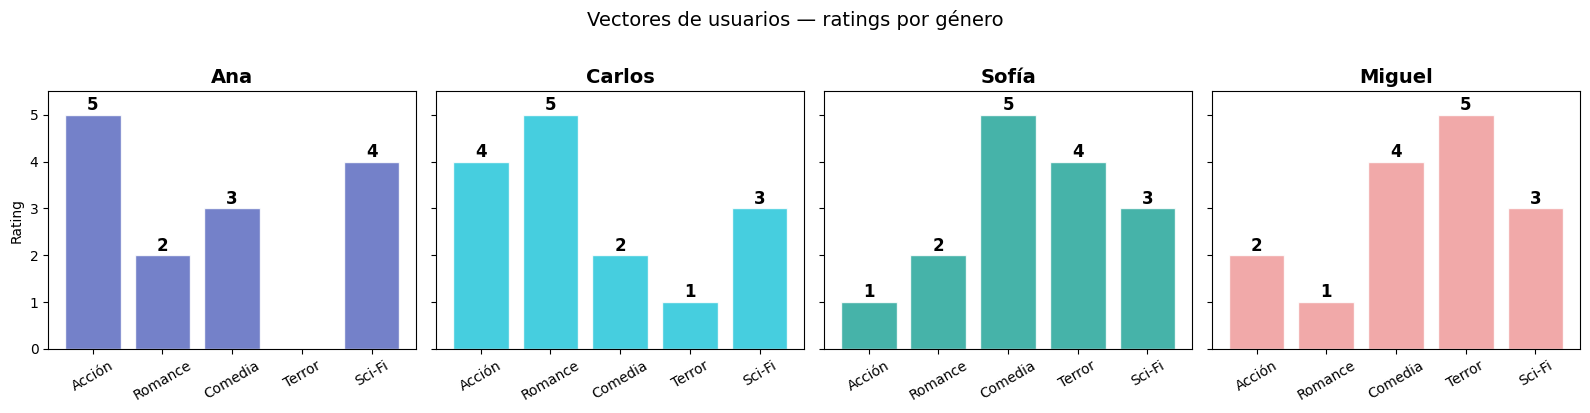

💡 Dos usuarios con barras similares tienen gustos parecidos.
   ¿Quién crees que se parece más a Ana?


In [26]:
# Visualicemos los vectores de usuarios
generos = ['Acción', 'Romance', 'Comedia', 'Terror', 'Sci-Fi']
usuarios = {'Ana': ana, 'Carlos': carlos, 'Sofía': sofia, 'Miguel': miguel}
colores  = ['#5C6BC0', '#26C6DA', '#26A69A', '#EF9A9A']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (nombre, vec), color in zip(axes, usuarios.items(), colores):
    bars = ax.bar(generos, vec, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(nombre, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 5.5)
    ax.set_ylabel('Rating' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vec):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(val), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Vectores de usuarios — ratings por género', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('💡 Dos usuarios con barras similares tienen gustos parecidos.')
print('   ¿Quién crees que se parece más a Ana?')

---
# PARTE 2 — Operaciones vectoriales

NumPy opera **elemento por elemento** — no necesitas loops.

| Operación | Código | ¿Para qué sirve en recomendación? |
|-----------|--------|------------------------------------|
| Suma | `v1 + v2` | Intereses combinados |
| Resta | `v1 - v2` | ¿En qué difieren? |
| Escalar | `k * v` | Amplificar/reducir preferencias |
| Media | `(v1+v2)/2` | Usuario "promedio" |

In [39]:
# Realicemos operaciones vectoriales entre usuarios
print(ana + carlos)

print(ana - carlos)

print(2 * ana)

print((ana + carlos)/2)


[9 7 5 1 7]
[ 1 -3  1 -1  1]
[10  4  6  0  8]
[4.5 3.5 2.5 0.5 3.5]


---
# PARTE 3 — Norma, producto escalar y similitud coseno

Para decidir qué usuarios son parecidos necesitamos una **métrica de similitud**.  
Hay tres conceptos que se construyen uno sobre otro:

```
Norma  →  Producto escalar  →  Similitud coseno
```

In [ ]:
# ── NORMA ────────────────────────────────────────────────
# La "longitud" del vector. Cuánto reseñó un usuario en total.

# sin usar numpy

#¿ANA SE PARECE MAS A MIGUEL O A CARLOS?

v1 = ana - miguel
v2 = ana - carlos

print(np.sqrt(sum(v1**2)))
print(np.sqrt(sum(v2**2)))


# funcion numpy

print(np.linalg.norm(ana - miguel))
print(np.linalg.norm(ana - carlos))

6.082762530298219
3.605551275463989
6.082762530298219
3.605551275463989


In [50]:
# ── PRODUCTO ESCALAR / PUNTO ─────────────────────────────────────
# Multiplica elemento a elemento y suma.
# Captura cuánto se "superponen" los gustos de dos usuarios.

# 1
print(np.dot(ana, miguel))

# 2
print(ana@carlos)


36
48


In [51]:
# ── SIMILITUD COSENO ─────────────────────────────────────
# Solución: dividir por las normas. Mide el ÁNGULO entre vectores.
# Rango: -1 a 1. En recomendación casi siempre 0 a 1.

def similitud_coseno(a, b):
    """
    Implementación manual de similitud coseno.
    cos(a, b) = (a · b) / (‖a‖ × ‖b‖)
    """

    prod_punto = a@b
    nom_a = np.linalg.norm(a)
    nom_b = np.linalg.norm(b)
    return prod_punto / (nom_a * nom_b)

# Comparación entre usuarios

print(similitud_coseno(ana,carlos))
print(similitud_coseno(ana,miguel))

0.8807710121010884
0.6605782590758164


In [ ]:
# DEMO: ¿Qué pasa si no normalizamos?
# Un usuario que calificó todo con 5 vs uno que calificó igual pero más bajo

usuario_entusiasta = np.array([5, 5, 5, 5, 5])  # califica todo 5
usuario_selectivo  = np.array([1, 1, 1, 1, 1])  # califica todo 1
usuario_parecido   = np.array([4, 4, 4, 4, 4])  # mismos gustos que entusiasta pero escala diferente

print('¿Quién es más "similar" al usuario entusiasta?')
print()
print(f'Producto escalar (entusiasta vs selectivo): {np.dot(usuario_entusiasta, usuario_selectivo)}')
print(f'Producto escalar (entusiasta vs parecido):  {np.dot(usuario_entusiasta, usuario_parecido)}')
print()
print(f'Coseno (entusiasta vs selectivo): {similitud_coseno(usuario_entusiasta, usuario_selectivo):.4f}')
print(f'Coseno (entusiasta vs parecido):  {similitud_coseno(usuario_entusiasta, usuario_parecido):.4f}')

¿Quién es más "similar" al usuario entusiasta?

Producto escalar (entusiasta vs selectivo): 25
Producto escalar (entusiasta vs parecido):  100

Coseno (entusiasta vs selectivo): 1.0000
Coseno (entusiasta vs parecido):  1.0000


---
# PARTE 4 — Construyendo el recomendador

Ahora lo juntamos todo. El algoritmo es:

1. Representar usuarios como vectores de ratings
2. Calcular matriz de similitud coseno entre todos
3. Para un usuario nuevo, encontrar el vecino más similar
4. Recomendar lo que ese vecino calificó alto y el usuario no ha visto

In [53]:
# Dataset un poco más grande: 8 usuarios, 6 películas
# Ratings 1-5, 0 = no ha visto

peliculas = ['Matrix', 'Titanic', 'Superbad', 'El Conjuro', 'Interstellar', 'La La Land']

ratings = np.array([
# Matrix  Titanic  Superbad  Conjuro  Interstellar  LaLaLand
    [5,      2,       3,        0,        5,            1],    # Ana
    [1,      5,       4,        2,        1,            5],    # Carlos
    [4,      3,       5,        1,        3,            3],    # Sofía
    [0,      1,       1,        5,        4,            0],    # Miguel
    [5,      1,       2,        0,        5,            2],    # Laura (similar a Ana)
    [2,      5,       3,        1,        2,            5],    # Pedro (similar a Carlos)
    [3,      4,       5,        2,        3,            4],    # Valeria
    [4,      0,       1,        5,        4,            0],    # Diego (similar a Miguel)
])

nombres = ['Ana', 'Carlos', 'Sofía', 'Miguel', 'Laura', 'Pedro', 'Valeria', 'Diego']

df = pd.DataFrame(ratings, index=nombres, columns=peliculas)
print('Dataset de ratings:')
df

Dataset de ratings:


,Matrix,Titanic,Superbad,El Conjuro,Interstellar,La La Land
Ana,5,2,3,0,5,1
Carlos,1,5,4,2,1,5
Sofía,4,3,5,1,3,3
Miguel,0,1,1,5,4,0
Laura,5,1,2,0,5,2
Pedro,2,5,3,1,2,5
Valeria,3,4,5,2,3,4
Diego,4,0,1,5,4,0


In [ ]:
# Calcular la matriz de similitud coseno entre usuarios
similitudes = cosine_similarity(ratings)
df_similitud = pd.DataFrame(similitudes, index=nombres, columns=nombres)
print('Matriz de similitud coseno entre usuarios:')
df_similitud.round(4)


Matriz de similitud coseno entre usuarios:


,Ana,Carlos,Sofía,Miguel,Laura,Pedro,Valeria,Diego
Ana,1.0000,0.5451,0.8878,0.4766,0.9764,0.6670,0.8016,0.7058
Carlos,0.5451,1.0000,0.8371,0.4134,0.5063,0.9718,0.9282,0.3404
Sofía,0.8878,0.8371,1.0000,0.4590,0.8463,0.8759,0.9752,0.6007
Miguel,0.4766,0.4134,0.4590,1.0000,0.4566,0.3884,0.5319,0.8410
Laura,0.9764,0.5063,0.8463,0.4566,1.0000,0.6473,0.7617,0.7180
Pedro,0.6670,0.9718,0.8759,0.3884,0.6473,1.0000,0.9414,0.3822
Valeria,0.8016,0.9282,0.9752,0.5319,0.7617,0.9414,1.0000,0.5762
Diego,0.7058,0.3404,0.6007,0.8410,0.7180,0.3822,0.5762,1.0000


<Axes: >

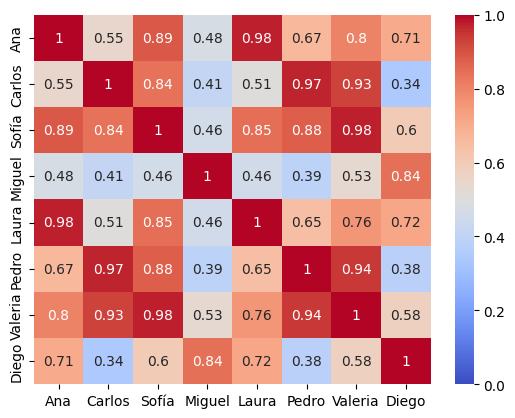

In [55]:
# Visualizar la matriz de similitud como heatmap
sns.heatmap(df_similitud, annot=True, cmap='coolwarm', vmin=0, vmax=1)

In [62]:
def recomendar_nuevo_usuario(ratings_nuevo, ratings_matrix, nombres_peliculas, n=3):
    # Similitud del nuevo usuario vs todos los existentes
    norma_nuevo = np.linalg.norm(ratings_nuevo)
    normas      = np.linalg.norm(ratings_matrix, axis=1)
    sims        = (ratings_matrix @ ratings_nuevo) / (normas * norma_nuevo)

    # Vecino más cercano
    vecino_idx  = np.argmax(sims)

    # Películas no vistas por el nuevo usuario → rating del vecino
    no_vistas   = np.where(ratings_nuevo == 0)[0]
    orden       = no_vistas[np.argsort(ratings_matrix[vecino_idx][no_vistas])[::-1][:n]]

    return {
        'recomendaciones': [nombres_peliculas[i] for i in orden],
        'basado_en':       nombres[vecino_idx],
        'similitud':       round(sims[vecino_idx], 3),
    }

# Uso — nuevo usuario que solo vio Matrix y El Conjuro
nuevo = np.array([0,2,4,0,1,0])
resultado = recomendar_nuevo_usuario(nuevo, ratings, peliculas)

print(f"Vecino más cercano: {resultado['basado_en']} (similitud: {resultado['similitud']})")
print(f"Recomendaciones:    {resultado['recomendaciones']}")


Vecino más cercano: Sofía (similitud: 0.762)
Recomendaciones:    ['Matrix', 'La La Land', 'El Conjuro']


---
# Resumen

| Concepto | Fórmula | Código NumPy | Para qué sirve |
|----------|---------|--------------|----------------|
| **Vector** | `[x₁, x₂, ..., xₙ]` | `np.array([...])` | Representar usuario/item |
| **Norma** | `√(x₁²+x₂²+...+xₙ²)` | `np.linalg.norm(v)` | Longitud del vector |
| **Producto escalar** | `Σ xᵢ·yᵢ` | `np.dot(a, b)` | Gustos en común |
| **Similitud coseno** | `(a·b)/(‖a‖‖b‖)` | `cosine_similarity(a, b)` | Similitud normalizada |

---
### ¿Por qué similitud coseno y no distancia euclidiana?

La distancia euclidiana mide **qué tan lejos** están dos puntos.  
La similitud coseno mide **en qué dirección apuntan** — el ángulo entre ellos.

Un usuario que calificó todo con 5 y otro que calificó todo con 4 tienen
**distancia euclidiana ≠ 0** pero **coseno = 1.0** — tienen los mismos gustos.

---
### Próximo webinar
**Matrices: tu dataset ES una matriz.**  
Veremos cómo el escalado y la transformación de datos son operaciones matriciales,  
y por qué eso hace que `StandardScaler` exista.